In [2]:
! pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\mduba\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import os

from langgraph.graph import StateGraph,START,END, add_messages
from pydantic import BaseModel, Field
from langgraph.prebuilt.tool_node import tools_condition,ToolNode
from typing import Literal, TypedDict,Annotated
from langchain_core.messages import BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder
from dotenv import load_dotenv
from langchain_core.tools import tool,InjectedToolCallId
import asyncio
from langchain_core.messages import HumanMessage,ToolMessage
from pymongo import AsyncMongoClient
from langchain_core.runnables import RunnableConfig
from bson import ObjectId
from bson.errors import InvalidId
from langgraph.types import Command
import json
from langgraph.prebuilt import InjectedState
import httpx

In [4]:
load_dotenv()

True

In [5]:
class AgentState(TypedDict):
  messages: Annotated[list[BaseMessage],add_messages]
  profile:dict
  jobs:list

In [6]:


ADZUNA_URL = "https://api.adzuna.com/v1/api/jobs/in/search/1"
ADZUNA_ID = os.getenv("ADZUNA_ID")
ADZUNA_API_KEY = os.getenv("ADZUNA_API_KEY")


@tool
async def fetch_jobs(
    state: Annotated[AgentState, InjectedState],
    config: RunnableConfig,
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Fetch job listings matching the user's target roles from their resume profile.
    Call retrive_user_resume_from_db first if the profile is not loaded yet."""

    profile = state.get("profile") or {}
    roles = profile.get("target_roles") or []
    if isinstance(roles, str):          # agar string aa gayi to list bana do
        roles = [roles]

    if not roles:
        return Command(update={"messages": [ToolMessage(
            "Error: profile not loaded or has no target_roles. "
            "Call retrive_user_resume_from_db first.",
            tool_call_id=tool_call_id)]})

    where = config["configurable"].get("location", "Noida")
    all_jobs, seen = [], set()

    try:
        async with httpx.AsyncClient(timeout=20) as client:
            for role in roles:
                r = await client.get(ADZUNA_URL, params={
                    "app_id": ADZUNA_ID,
                    "app_key": ADZUNA_API_KEY,
                    "what": role,
                    "where": where,
                    "results_per_page": 5,
                })
                r.raise_for_status()

                for j in r.json().get("results", []):
                    if j["id"] in seen:
                        continue
                    seen.add(j["id"])
                    all_jobs.append({
                        "role_searched": role,
                        "title": j.get("title"),
                        "company": (j.get("company") or {}).get("display_name"),
                        "description": j.get("description"),
                        "salary_min": j.get("salary_min"),
                        "salary_max": j.get("salary_max"),
                        "salary_is_predicted": j.get("salary_is_predicted"),
                        "location": (j.get("location") or {}).get("display_name"),
                        "url": j.get("redirect_url"),
                    })
        llm_view = [{**job, "description": (job["description"] or "")[:200]} for job in all_jobs]

        return Command(update={
            "jobs": all_jobs,
            "messages": [ToolMessage(json.dumps(llm_view, default=str), tool_call_id=tool_call_id)],
        })
    except Exception as e:
        return Command(update={"messages": [ToolMessage(
            f"Error: {e!r}", tool_call_id=tool_call_id)]})

In [7]:
@tool
async def retrive_user_resume_from_db( config:RunnableConfig,tool_call_id:Annotated[str,InjectedToolCallId])->Command:
   """"Get the current user's resume profile (skills, experience, education, etc.) from the database.
       Use this tool when the user asks for job or anything that needs their resume."""

   conf=config["configurable"]["collection"]
   id=config["configurable"]["id"]
   try:
    obj_id=ObjectId(id)
   except (InvalidId, TypeError ,KeyError):
    return {"error":"Invalid ID format missing resume id. Please provide a valid ObjectId string."}
   try:
      doc=await conf.find_one({"_id":obj_id},{"_id":0,"profile":1})
      if not doc or "profile" not in doc:
        return Command(update={
            "messages":[ToolMessage("Error:No resume found for the provided ID.",tool_call_id=tool_call_id)]
        })
      return Command(update={
            "profile":doc["profile"],
            "messages":[ToolMessage(json.dumps(doc,default=str),tool_call_id=tool_call_id)]
        })
   except Exception as e:
    return Command(update={
        "messages":[ToolMessage(f"Error: {e!r}", tool_call_id=tool_call_id)]
    })

In [8]:
router_llm=ChatGoogleGenerativeAI(model="gemma-4-31b-it")
tools=[retrive_user_resume_from_db,fetch_jobs]
tool_binded_llm=router_llm.bind_tools(tools)
tool_node=ToolNode(tools=tools)

In [9]:
prompt=ChatPromptTemplate.from_messages([
    ("system","You are a helpful assistant. Use tools when needed, otherwise answer the user's question directly."),
    MessagesPlaceholder("messages")
  ])

In [10]:
router_chain=prompt|tool_binded_llm

In [11]:
async def router(state:AgentState):
  response=await router_chain.ainvoke({"messages": state["messages"]})
  return {"messages":[response]}

In [12]:
workflow=StateGraph(AgentState)

workflow.add_node("router",router)
workflow.add_node("tool_node",tool_node)


workflow.add_edge(START,"router")
workflow.add_conditional_edges("router",tools_condition ,{"tools":"tool_node",END:END})
workflow.add_edge("tool_node","router")

In [13]:
agent=workflow.compile()

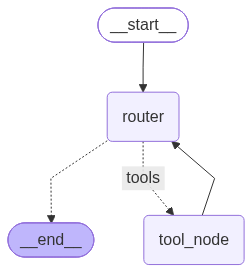

In [14]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [15]:
client=AsyncMongoClient(os.getenv("MONGODB_URI"))
db= client.get_database("resume")
collection=db.get_collection("profiles")


In [19]:
result=await agent.ainvoke({"messages":[HumanMessage(content="fetch resume from db and find relevent jobs that i can apply based on my resume?")]},config={"configurable":{"collection":collection,"id":"6ac0af5f2f104c38f3ee10ab","location":"Pune"}})

In [27]:
result["messages"][4].content


"Error invoking tool 'fetch_jobs' with kwargs {} with error:\n \n Please fix the error and try again."